# Sensitivity-Aware Amortized Bayesian Inference

_Authors: Lasse Elsemüller, Stefan T. Radev_

In [1]:
import datetime

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import bayesflow as bf

import keras

INFO:2026-02-27 21:52:49,778:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'
/home/space/Projects/bayesflow/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Introduction <a class="anchor" id="introduction"></a>

In this tutorial, we will walk through an example of **sensitivity-aware amortized Bayesian inference**, i.e., the potentially large-scale sensitivity analyses enabled by amortization.
These sensitivity analyses can be conducted on all major dimensions of a Bayesian analysis:
- **Prior & Likelihood**: By conditioning on additional context variables encoding different configurations of plausible probabilistic models
- **Data**: By leveraging the speed of amortized inference to inspect the range of results for a broad range of plausible dataset variations
- **Approximator**: By using the agreement of an ensemble of neural approximators as a measurement for stability in the simulated (e.g., training convergence) and real (e.g., out-of-distribution errors induced by model misspecification) world.
Since such large-scale sensitivity analyses lead by definition to high-dimensional and thus complex results, we will (i) build upon the [existing SIR tutorial](https://github.com/bayesflow-org/bayesflow/blob/main/examples/SIR_Posterior_Estimation.ipynb) and (ii) refer to the separate ensemble tutorial notebook [TODO!] to illustrate separately how approximator sensitivity can be inspected in BayesFlow.
Please refer to the [Sensitivity-Aware Amortized Bayesian Inference](https://openreview.net/forum?id=Kxtpa9rvM0) publication for further information.

## Defining the Simulator <a class="anchor" id="defining_the_generative"></a>

In [6]:
RNG = np.random.default_rng(2026)

### Prior <a class="anchor" id="prior"></a>

We start by defining a context generator that samples from the set of plausible prior and likelihood configurations. Here, we consider two plausible SIR likelihoods and systematically vary the confidence encoded in our prior distributions via power scaling.
TODO: Describe difference between likelihoods

In [7]:
def context_generator(alpha_lower_bound=0.5, alpha_upper_bound=2.0):
    """
    Generates likelihood and prior context:
    - `model_index`: 0 for SIR model, 1 for SEIR model
    - `alphas`: Uniform power-scaling parameters for the prior distributions.
                Samples in log space to have evenly distributed samples below and above 1 (= no scaling).
    """
    model_index=RNG.binomial(n=1, p=0.5)
    log_samples = RNG.uniform(np.log10(alpha_lower_bound), np.log10(alpha_upper_bound), size=6)
    alphas = np.power(10, log_samples)
    return dict(model_index=model_index, alphas=alphas)

def prior(model_index, alphas):
    """
    Generates a random draw from the joint prior. Each marginal prior has its own scaling parameter.
    See table 1 in https://arxiv.org/abs/2107.14054 for details on power-scaled distributions.
    """

    lambd = RNG.lognormal(mean=np.log(0.4), sigma=0.5 / np.sqrt(alphas[0]))
    mu = RNG.lognormal(mean=np.log(1 / 8), sigma=0.2 / np.sqrt(alphas[1]))
    D = RNG.lognormal(mean=np.log(8), sigma=0.2 / np.sqrt(alphas[2]))
    I0 = RNG.gamma(shape=2 * alphas[3] - alphas[3] + 1, scale=20 / alphas[3])
    psi = RNG.exponential(5 / alphas[4])

    if model_index == 0:
        # Dummy parameter for SIR model, exponentiated since we take the log in the adapter later
        gamma = np.expm1(RNG.standard_normal())
    elif model_index == 1:
        # Extra parameter of the SEIR model
        gamma = RNG.lognormal(mean=np.log(1 / 6.5), sigma=0.5 / np.sqrt(alphas[5]))

    return {"lambd": lambd, "mu": mu, "D": D, "I0": I0, "psi": psi, "gamma": gamma}

It is helpful to visually inspect both the symmetric scaling factor distribution itself as well as the scaled (marginal) prior distributions resulting from the scaling:

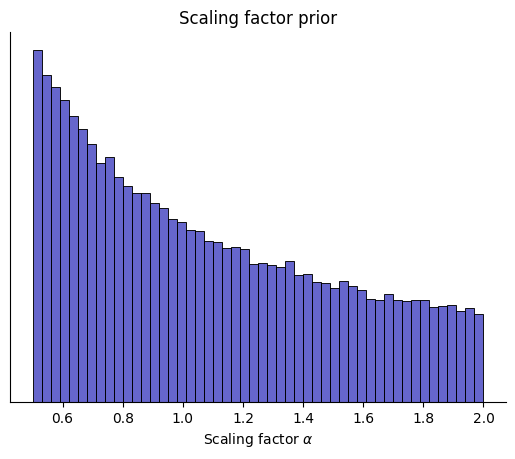

In [8]:
sns.histplot(np.power(10, RNG.uniform(np.log10(0.5), np.log10(2), size=100000)), color="#0000AA", alpha=0.6)
plt.xlabel(r"Scaling factor $\alpha$")
plt.ylabel("")
plt.yticks([])
plt.title("Scaling factor prior")
sns.despine()

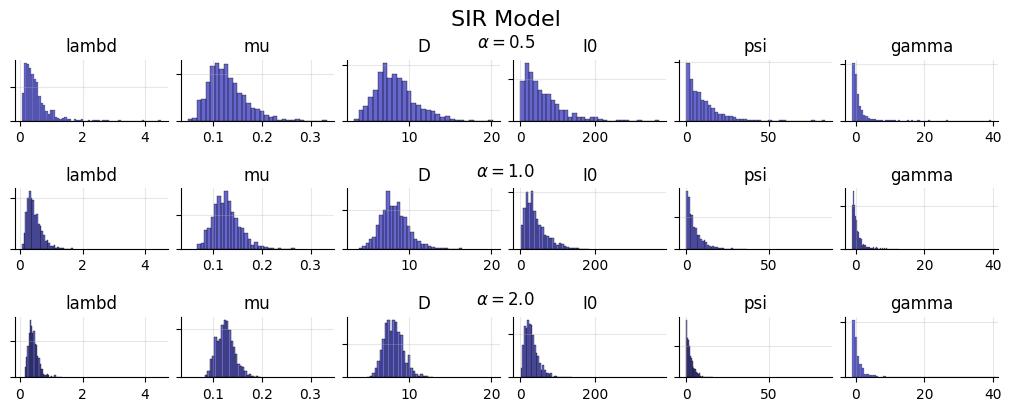

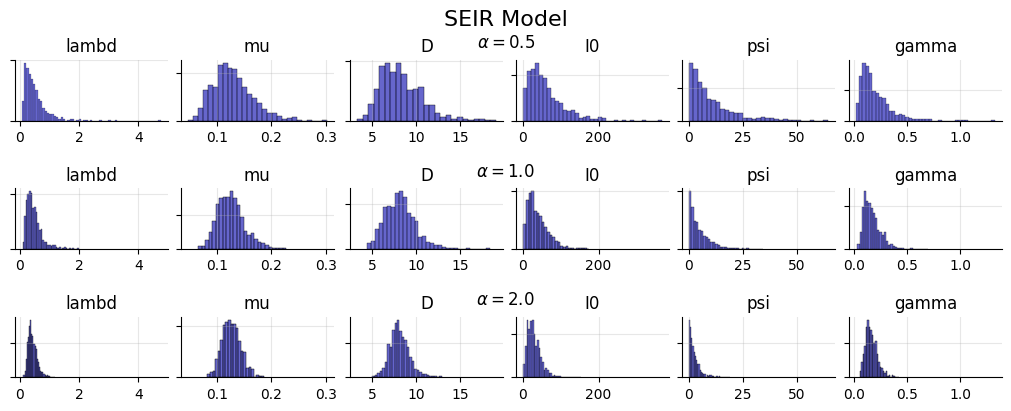

In [10]:
alpha_values = [0.5, 1.0, 2.0]
model_indices = {"SIR Model": 0, "SEIR Model": 1}

for model_name, model_index in model_indices.items():
    fig = plt.figure(constrained_layout=True, figsize=(10, 4))
    fig.suptitle(model_name, fontsize=16)
    subfigs = fig.subfigures(nrows=3, ncols=1, hspace=0.1)
    all_axes = [] 

    for i, alpha in enumerate(alpha_values):

        axes = subfigs[i].subplots(nrows=1, ncols=6)
        all_axes.append(axes)
        subfigs[i].suptitle(r'$\alpha = {}$'.format(alpha), y=1.0)

        alphas = np.repeat(alpha, 6)
        samples = [prior(model_index, alphas) for _ in range(1000)]

        for j, param_key in enumerate(samples[0].keys()):
            param_data = np.array([s[param_key] for s in samples])

            ax = axes[j]
            ax.grid(alpha=0.3)
            sns.histplot(param_data, ax=ax, stat="density", alpha=0.6, color="#0000AA")
            ax.set_title(param_key)
            ax.set_ylabel('')
            ax.set_yticklabels([])
            ax.tick_params(axis="both", which="major")

            if i > 0:
                ax.set_xlim(all_axes[0][j].get_xlim())

            sns.despine()
    plt.show()

### Observation Model (Implicit Likelihood Function) <a class="anchor" id="simulator__implicit_likelihood"></a>

In [11]:
def convert_params(mu, phi):
    """Helper function to convert mean/dispersion parameterization of a negative binomial to N and p,
    as expected by numpy's negative_binomial.

    See https://en.wikipedia.org/wiki/Negative_binomial_distribution#Alternative_formulations
    """

    r = phi
    var = mu + 1 / r * mu**2
    p = (var - mu) / var
    return r, 1 - p


def outbreak_simulator(model_index, lambd, mu, D, I0, psi, gamma, N=83e6, T=14, eps=1e-5):
    """
    Performs a forward simulation from epidemiological model based on `model_index`.
    - `model_index==0`: SIR model
    - `model_index==1`: SEIR model 
    """

    # Extract parameters and round I0 and D
    I0 = np.ceil(I0)
    D = int(round(D))

    # Initial conditions

    if model_index == 0:
        S, I, R = [N - I0], [I0], [0]
    else:
        S, E, I, R = [N - I0], [0], [I0], [0]

    # Reported new cases
    C = [I0]

    # Simulate T-1 timesteps
    for t in range(1, T + D):

        if model_index == 0:
            I_new = lambd * (I[-1] * S[-1] / N) 
            S_t = S[-1] - I_new
            I_t = np.clip(I[-1] + I_new - mu * I[-1], 0.0, N)
            R_t = np.clip(R[-1] + mu * I[-1], 0.0, N)
        elif model_index == 1: 
            E_new = lambd * (I[-1] * S[-1] / N)
            S_t = S[-1] - E_new
            I_new = np.clip(gamma * E[-1], 0.0, N)
            E_t = np.clip(E[-1] + E_new - I_new, 0.0, N)
            I_t = np.clip(I[-1] + I_new - mu * I[-1], 0.0, N)
            R_t = np.clip(R[-1] + mu * I[-1], 0.0, N)

        # Track
        S.append(S_t)
        I.append(I_t)
        R.append(R_t)
        C.append(I_new)
        if model_index == 1:
            E.append(E_t)

    reparam = convert_params(np.clip(np.array(C[D:]), 0, N) + eps, psi)
    try:
        C_obs = RNG.negative_binomial(reparam[0], reparam[1])
    except ValueError:
        C_obs = np.full(T, np.nan)
    return dict(cases=C_obs)

### Loading Real Data <a class="anchor" id="loading_real_data"></a>

In [12]:
def load_data():
    """Helper function to load cumulative cases and transform them to new cases."""

    confirmed_cases_url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"
    confirmed_cases = pd.read_csv(confirmed_cases_url, sep=",")

    date_data_begin = datetime.date(2020, 3, 1)
    date_data_end = datetime.date(2020, 3, 15)
    format_date = lambda date_py: f"{date_py.month}/{date_py.day}/{str(date_py.year)[2:4]}"
    date_formatted_begin = format_date(date_data_begin)
    date_formatted_end = format_date(date_data_end)

    cases_obs = np.array(
        confirmed_cases.loc[confirmed_cases["Country/Region"] == "Germany", date_formatted_begin:date_formatted_end]
    )[0]
    new_cases_obs = np.diff(cases_obs)
    return new_cases_obs

### Stitiching Things Together <a class="anchor" id="generative_model"></a>

In [13]:
simulator = bf.make_simulator([context_generator, prior, outbreak_simulator])

In [14]:
test_sims = simulator.sample(batch_size=2)

print(test_sims["lambd"].shape)
print(test_sims["D"].shape)
print(test_sims["cases"].shape)

(2, 1)
(2, 1)
(2, 14)


## Defining the Adapter

In [ ]:
adapter = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")
    .as_time_series("cases")
    .concatenate(["lambd", "mu", "D", "I0", "psi", "gamma"], into="inference_variables")
    # this is the new part - the network is aware of the prior / model
    .concatenate(["model_index", "alphas"], into="inference_conditions")
    .rename("cases", "summary_variables")
    # since all our variables are non-negative (zero or larger), the next call transforms them
    # to the unconstrained real space and can be back-transformed under the hood
    .log(["inference_variables", "summary_variables"], p1=True)  # TODO: Also for inference_conditions?
)

In [16]:
adapter

Adapter([0: ConvertDType -> 1: AsTimeSeries -> 2: Concatenate(['lambd', 'mu', 'D', 'I0', 'psi', 'gamma'] -> 'inference_variables') -> 3: Concatenate(['model_index', 'alphas'] -> 'inference_conditions') -> 4: Rename('cases' -> 'summary_variables') -> 5: Log])

In [17]:
# Let's check out the new shapes
adapted_sims = adapter(simulator.sample(2))
print(adapted_sims["summary_variables"].shape)
print(adapted_sims["inference_variables"].shape)
print(adapted_sims["inference_conditions"].shape)

(2, 14, 1)
(2, 6)
(2, 7)


## Defining the Neural Approximator <a class="anchor" id="defining_the_neural"></a>

### Custom Summary Network

In [81]:
class GRU(bf.networks.SummaryNetwork):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

        self.gru = keras.layers.GRU(64)
        self.summary_stats = keras.layers.Dense(8)
        
    def call(self, time_series):
        """Compresses time_series of shape (batch_size, T, 1) into summaries of shape (batch_size, 8)."""

        summary = self.gru(time_series)
        summary = self.summary_stats(summary)
        return summary

### Workflow

In [86]:
workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=bf.networks.FlowMatching(subnetwork_kwargs={"widths": (64, 64)}),
    summary_network=GRU(),
    standardize=None # no need to standardize due to log-transform
)

## Training <a class="anchor" id="training"></a>

In [87]:
%%time
_ = workflow.simulate(32)

CPU times: user 10.3 ms, sys: 2.94 ms, total: 13.2 ms
Wall time: 12.6 ms


### Generating Offline Data <a class="anchor" id="generating_offline_data"></a>

In [84]:
training_data = workflow.simulate(10_000)
validation_data = workflow.simulate(300)

In [88]:
history = workflow.fit_offline(
    data=training_data, 
    epochs=300, 
    batch_size=32, 
    validation_data=validation_data,
    verbose=1
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 1.2747 - val_loss: 0.7300
Epoch 2/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - loss: 0.8382 - val_loss: 0.6999
Epoch 3/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 934us/step - loss: 0.7962 - val_loss: 0.6875
Epoch 4/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step - loss: 0.7376 - val_loss: 0.6507
Epoch 5/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 933us/step - loss: 0.7029 - val_loss: 0.6691
Epoch 6/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - loss: 0.6835 - val_loss: 0.6225
Epoch 7/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step - loss: 0.6454 - val_loss: 0.6018
Epoch 8/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step - loss: 0.6243 - val_loss: 0.5984
Epoch 9/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 934us/step - loss: 0.6142 - val_loss: 0.5421
Epoch 10/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step - loss: 0.6078 - val_loss: 0.5397
Epoch 11/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step - loss: 0.5933 - val_loss: 0.5240
Epoch 12/300
313/313

INFO:bayesflow:Training completed in 1.64 minutes.


## Diagnostics

⚠️ Prepare for high-dimensional results! We are taking a deep dive into sensitivity across all major modeling dimensions, which naturally results in a large number of plots.

Sensitivity-aware ABI gives you all the tools for efficient sensitivity analyses. It will be up to you to decide the resolution with which you want to inspect the different dimensions. For example, if you amortize across a range of priors, it might be sufficient to look at marginal diagnostics across all prior variations. However, if you amortize across different observation models, you might want to look at diagnostics for each observation model separately.

### Inspecting the Loss <a class="anchor" id="inspecting_the_loss"></a>

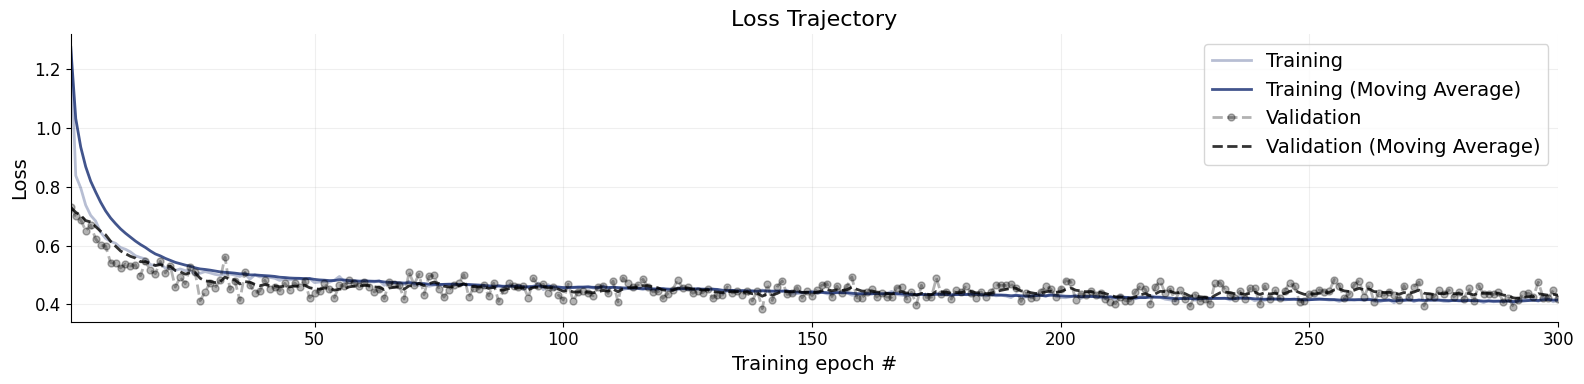

In [89]:
f = bf.diagnostics.plots.loss(history)

## Validation: Performance & Approximator Sensitivity in the Simulated World

Here, we split validation by likelihood to make sure that we appropriately learned inverse inference for both SIR likelihood, whereas we reduce granularity and thus complexity by looking at the marginal validation across the full prior spectrum implied by power scaling.

In [90]:
num_datasets = 1000
num_samples = 1000
all_test_sims = workflow.simulate(num_datasets)
test_sims = {}
samples = {}

for model_name, model_index in model_indices.items():
    mask = all_test_sims["model_index"].flatten() == model_index
    test_sims[model_name] = {k: v[mask] for k, v in all_test_sims.items()}
    samples[model_name] = workflow.sample(conditions=test_sims[model_name], num_samples=num_samples, batch_size=100)
    print(test_sims[model_name]["cases"].shape, samples[model_name]["lambd"].shape)

Sampling: 100%|██████████| 5/5 [00:20<00:00,  4.08s/batch]
INFO:bayesflow:Sampling completed in 20.45 seconds.


(497, 14) (497, 1000, 1)


Sampling: 100%|██████████| 6/6 [00:21<00:00,  3.58s/batch]
INFO:bayesflow:Sampling completed in 21.52 seconds.


(503, 14) (503, 1000, 1)


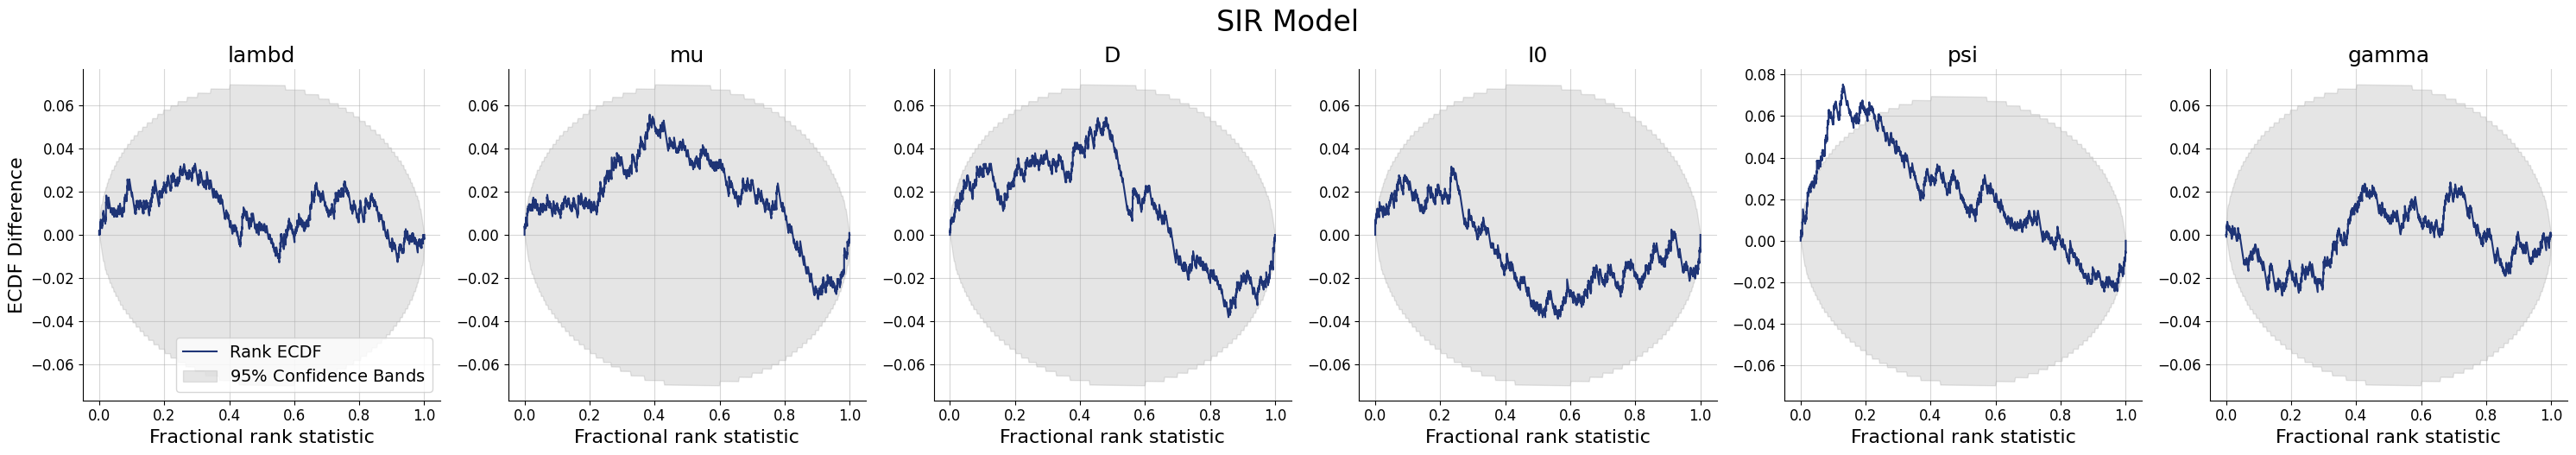

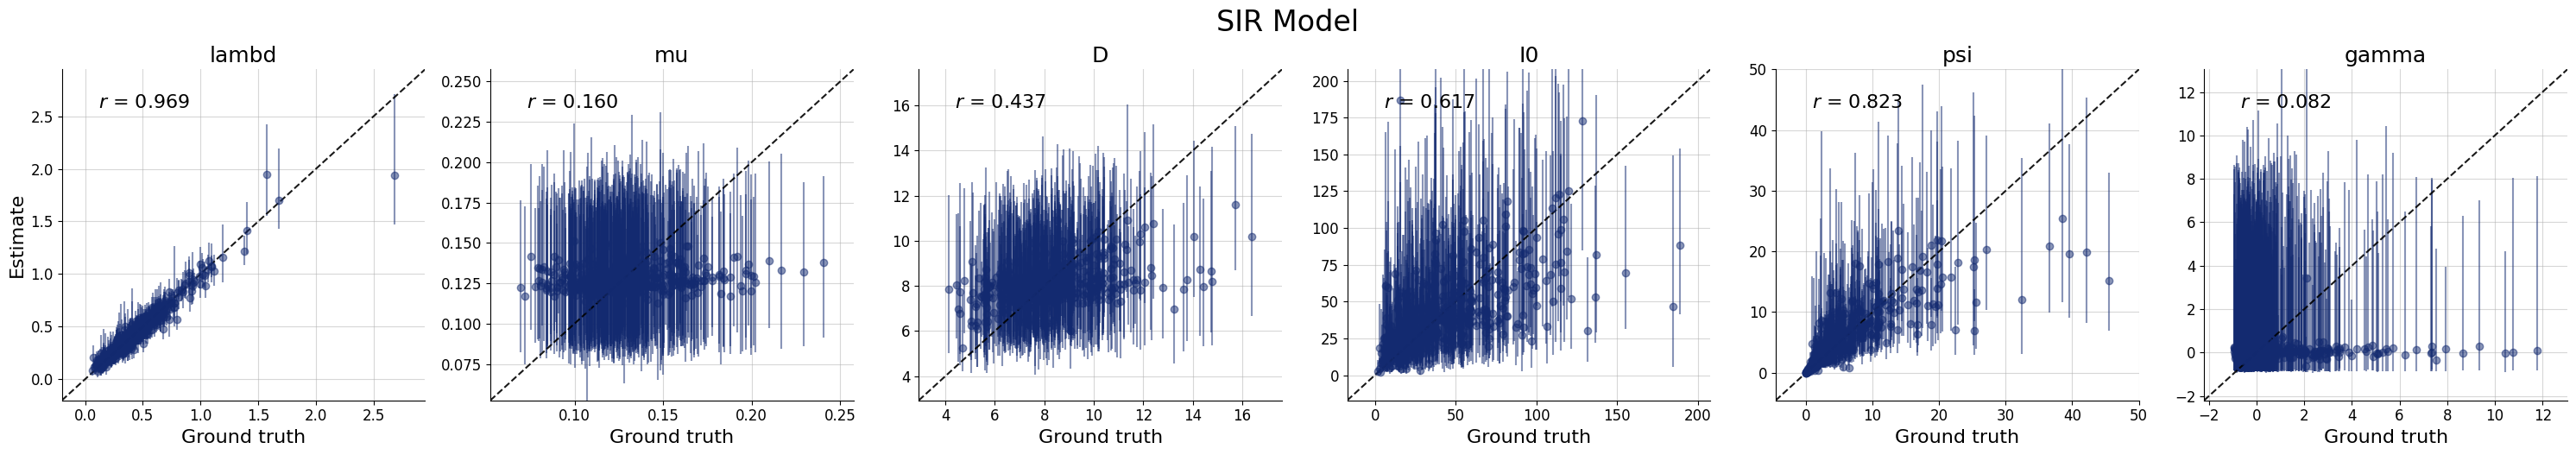

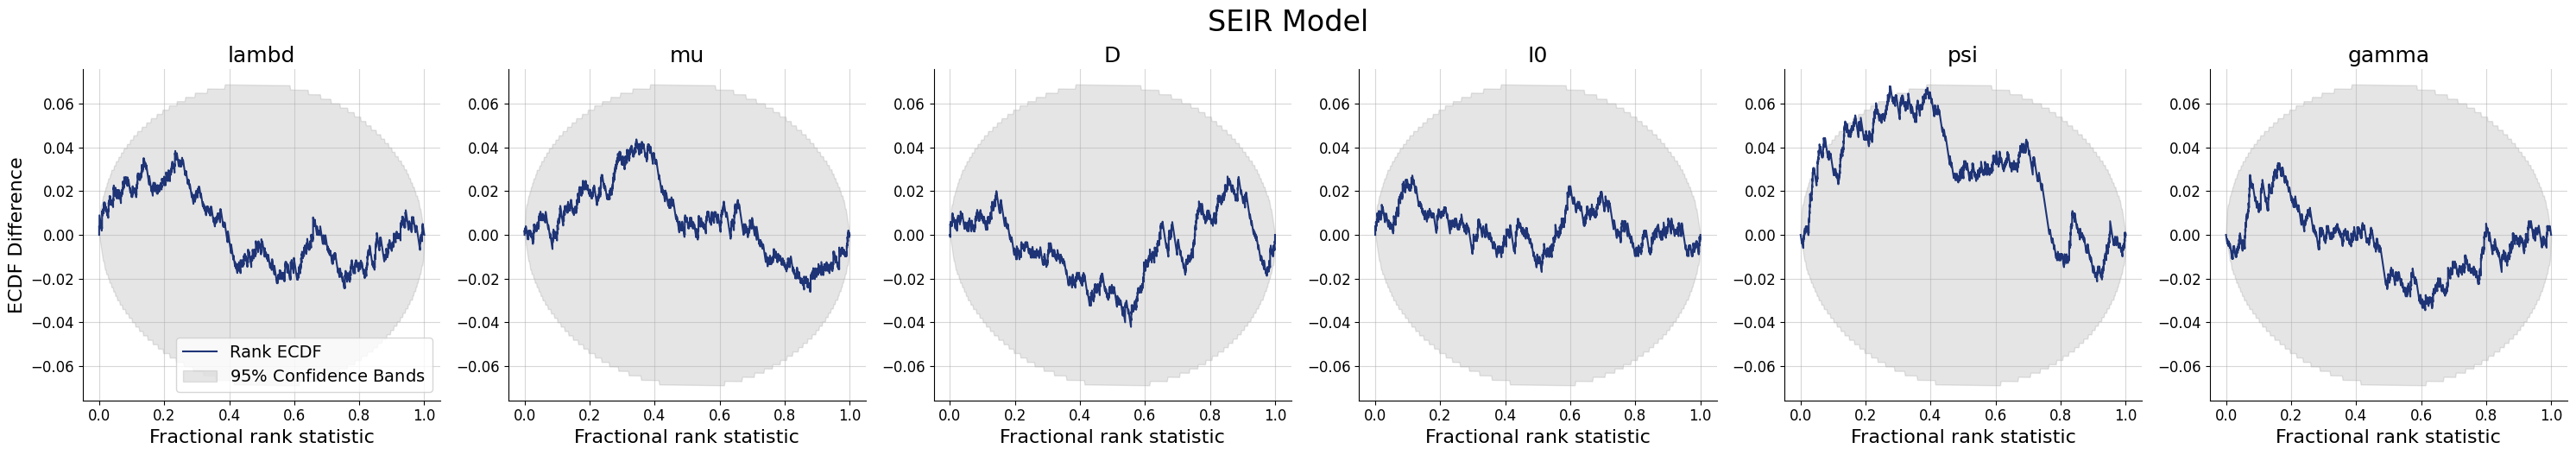

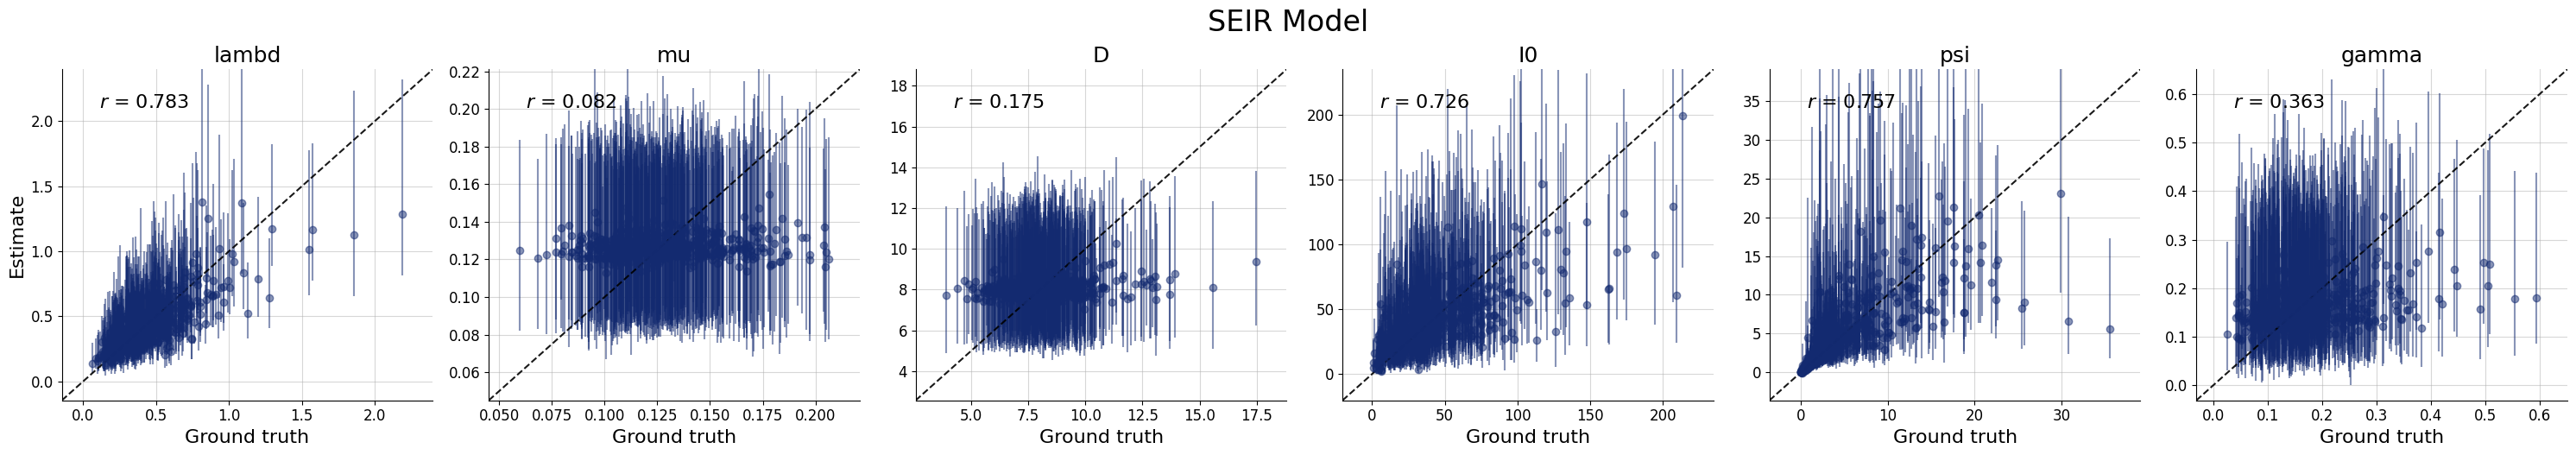

In [91]:
for model_name, model_index in model_indices.items():
    f = bf.diagnostics.plots.calibration_ecdf(samples[model_name], test_sims[model_name], difference=True, suptitle=model_name)
    f.suptitle(model_name, y=1.05, fontsize=24)
    f = bf.diagnostics.plots.recovery(samples[model_name], test_sims[model_name])
    f.suptitle(model_name, y=1.05, fontsize=24)

### Automatic Diagnostics

We can also use the powerful built-in diagnostic functions of BayesFlow, but have to be careful about the dimensions we want to inspect.

For example, if you want to inspect approximation performance for the different computational models, be careful to pass the data for the respective model only! If we would only pass an integer to `compute_default_diagnostics`, we will always look at marginal diagnostics across all models as `compute_default_diagnostics` will internally simulate new data with random model indeces.

In [92]:
for model_name, model_index in model_indices.items():
    metrics = workflow.compute_default_diagnostics(test_data=test_sims[model_name])
    print(f"Diagnostics for {model_name}:")
    display(metrics)

Sampling: 100%|██████████| 1/1 [00:14<00:00, 14.53s/batch]


Diagnostics for SIR Model:


,lambd,mu,D,I0,psi,gamma
NRMSE,0.031303,0.208052,0.178336,0.180684,0.104878,0.212438
Log Gamma,2.742542,1.431971,0.449139,-2.526701,-4.397965,3.650860
Calibration Error,0.010269,0.016618,0.039444,0.024801,0.040517,0.010545
Posterior Contraction,0.969571,0.197405,0.442418,0.599850,0.944951,0.000000


Sampling: 100%|██████████| 1/1 [00:14<00:00, 14.64s/batch]


Diagnostics for SEIR Model:


,lambd,mu,D,I0,psi,gamma
NRMSE,0.097983,0.247793,0.168728,0.157523,0.149172,0.205131
Log Gamma,2.020148,2.501699,1.637517,2.020148,-0.812428,3.709664
Calibration Error,0.018011,0.024851,0.008650,0.009451,0.032714,0.024065
Posterior Contraction,0.725339,0.104753,0.123854,0.632251,0.856307,0.095448


## Inference: Prior & Likelihood Sensitivity in the Real World

### Prior & Likelihood Sensitivity

Let's first inspect prior and likelihood sensitivity graphically via posterior retrodictive checks:

In [93]:
# Our real-data loader returns the time series as a 1D array
obs_cases = load_data()

In [94]:
def plot_ppc(model_name, model_index, alpha, samples, obs_cases, logscale=False, color="#132a70", font_size=12, cases_label="Reported cases"):
    """
    Helper function to perform some plotting of the posterior predictive.
    """
    # Plot settings
    plt.rcParams["font.size"] = font_size
    T = len(obs_cases)

    # Re-simulations
    sims = []
    for i in range(samples.shape[0]):
        # Note - simulator returns 2D arrays of shape (T, 1), so we remove trailing dim
        sim_cases = outbreak_simulator(model_index, *samples.values[i])
        sims.append(sim_cases["cases"])
    sims = np.array(sims)

    # Remove simulations with NaNs (invalid sims from simulator)
    valid_mask = ~np.any(np.isnan(sims), axis=1)
    if not np.any(valid_mask):
        print(f"No valid simulations for {model_name}, alpha={alpha}. Skipping PPC plot.")
        return f
    sims = sims[valid_mask]
    print(f"Fraction of invalid simulations for {model_name}, alpha={alpha}: {(1 - np.mean(valid_mask)):.2%}")

    # Compute quantiles for each t = 1,...,T
    qs_90 = np.quantile(sims, q=[0.05, 0.95], axis=0)

    # Plot observed data
    ax.plot(obs_cases, marker="o", label=cases_label, color="black", linestyle="dashed", alpha=0.8)
    
    # Plot median predictions
    ax.plot(np.median(sims, axis=0), label=rf"$\alpha$ = {alpha}: Median predicted cases", color=color)    
    
    # Add compatibility intervals (also called credible intervals)
    ax.fill_between(range(T), qs_90[0], qs_90[1], color=color, alpha=0.1, label=rf"$\alpha$ = {alpha}: 90% CI")

    # Grid and schmuck
    ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_xlabel("Days since pandemic onset")
    ax.set_ylabel("Number of cases")
    ax.minorticks_off()
    if logscale:
        ax.set_yscale("log")
    ax.legend(fontsize=int(font_size * 0.75))
    ax.set_title(model_name, fontsize=font_size)
    return f

We now obtain posterior predictive samples for our different likelihood and prior configurations.
Let's inspect the posterior means and standard deviations to get a first feeling for our results in the parameter space before visualizing them in the data space:

In [95]:
samples_obs = {}
posterior_means = {}
posterior_stds = {}

for model_name, model_index in model_indices.items():
    samples_obs[model_name] = {}
    for alpha in alpha_values:
        # Note that we transform the 1D array into shape (1, T), indicating one time series
        samples_obs[model_name][alpha] = workflow.sample(conditions={"cases": obs_cases[None, :], "model_index": np.array([[model_index]]), "alphas": np.repeat(alpha, 6)[None, :]}, num_samples=num_samples)
        # Convert into a nice format 2D data frame
        samples_obs[model_name][alpha] = workflow.samples_to_data_frame(samples_obs[model_name][alpha])
        posterior_means[(model_name, alpha)] = samples_obs[model_name][alpha].mean(axis=0)
        posterior_stds[(model_name, alpha)] = samples_obs[model_name][alpha].std(axis=0)

print("Posterior means:")
display(pd.DataFrame.from_dict(posterior_means, orient="index"))
print("Posterior standard deviations:")
display(pd.DataFrame.from_dict(posterior_stds, orient="index"))

Sampling: 100%|██████████| 1/1 [00:03<00:00,  3.62s/batch]
INFO:bayesflow:Sampling completed in 3.62 seconds.
Sampling: 100%|██████████| 1/1 [00:01<00:00,  1.39s/batch]
INFO:bayesflow:Sampling completed in 1.39 seconds.
Sampling: 100%|██████████| 1/1 [00:01<00:00,  1.40s/batch]
INFO:bayesflow:Sampling completed in 1.40 seconds.
Sampling: 100%|██████████| 1/1 [00:01<00:00,  1.40s/batch]
INFO:bayesflow:Sampling completed in 1.40 seconds.
Sampling: 100%|██████████| 1/1 [00:01<00:00,  1.46s/batch]
INFO:bayesflow:Sampling completed in 1.46 seconds.
Sampling: 100%|██████████| 1/1 [00:01<00:00,  1.41s/batch]
INFO:bayesflow:Sampling completed in 1.41 seconds.


Posterior means:


lambd        mu         D         I0       psi     gamma
SIR Model  0.5  0.401509  0.125097  7.511498  30.563943  6.577758  1.134758
           1.0  0.395183  0.127947  7.847412  28.825939  6.468801  0.883428
           2.0  0.391641  0.119454  7.978120  27.146122  4.674014  1.003570
SEIR Model 0.5  0.880167  0.122235  8.028761  59.420374  6.165298  0.239693
           1.0  0.866790  0.125481  8.148246  51.204659  5.582626  0.247223
           2.0  0.783422  0.121885  8.800596  44.921793  4.975922  0.240720

Posterior standard deviations:


lambd        mu         D         I0       psi     gamma
SIR Model  0.5  0.050061  0.029731  1.685602  17.322288  2.575626  2.359013
           1.0  0.041219  0.024126  1.512554  15.405996  2.271445  2.296240
           2.0  0.035045  0.019128  1.031821  10.656471  1.661197  2.828739
SEIR Model 0.5  0.268580  0.029709  1.825469  30.540264  2.196538  0.130468
           1.0  0.228515  0.025142  1.609015  24.461518  2.036284  0.117604
           2.0  0.130925  0.017238  1.117815  16.469877  1.954777  0.074423

Let's now move on to visualize the different posterior retrodictive patterns implied by the parameter posteriors. Some edge samples might break the simulator, which we filter for the resimulations but still take into account for our sensitivity analysis:

Fraction of invalid simulations for SIR Model, alpha=0.5: 0.00%
Fraction of invalid simulations for SIR Model, alpha=1.0: 0.00%
Fraction of invalid simulations for SIR Model, alpha=2.0: 0.00%
Fraction of invalid simulations for SEIR Model, alpha=0.5: 0.00%
Fraction of invalid simulations for SEIR Model, alpha=1.0: 0.00%
Fraction of invalid simulations for SEIR Model, alpha=2.0: 0.00%


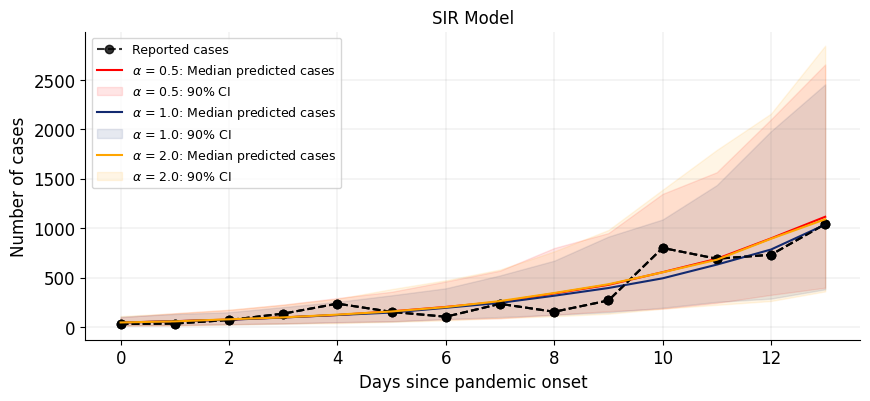

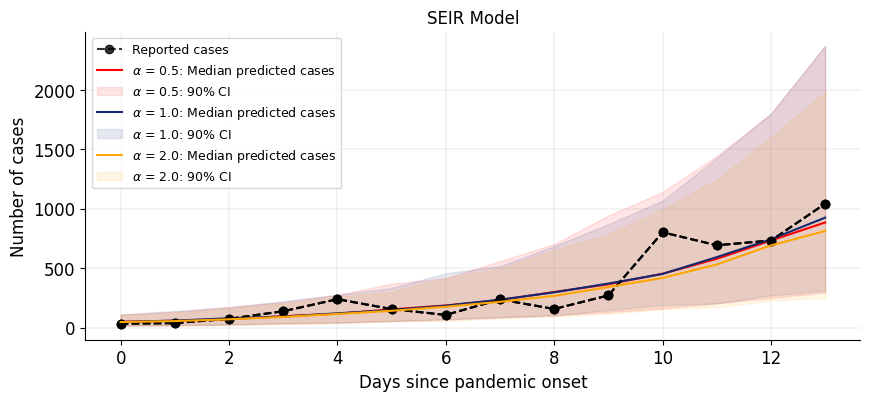

In [96]:
alpha_values = [0.5, 1.0, 2.0]
alpha_colors = {0.5: "red", 1.0: "#132a70", 2.0: "orange"}

for model_name, model_index in model_indices.items():
    f, ax = plt.subplots(1, 1, figsize=(10, 4))
    for alpha in alpha_values:
        cases_label = "Reported cases" if alpha == 0.5 else None
        f = plot_ppc(model_name, model_index, alpha, samples_obs[model_name][alpha], obs_cases, color=alpha_colors[alpha], cases_label=cases_label)

There seems to be little sensitivity with reagrd to the observation model or prior, apart from small qualitative differences.

#### Data Sensitivity

Data sensitivity can be assessed by observing the change in results for different variations of the data. These variations can result from systematically varying preprocessing choices, or simply from resampling the data. Here, we use a block bootstrap approach to generate alternative versions of the observed time series. For each bootstrap replicate, we perform posterior inference and then inspect variability in posterior means and posterior predictive medians across the bootstrap replicates. Building upon our earlier results, we consider both likelihoods, but fix the priors in their original (unscaled) form.

In [ ]:
def block_bootstrap_series(series, block_size, n_bootstraps, rng=RNG):
    """Return an array of shape (n_bootstraps, T) with block-bootstrapped series."""

    series = np.asarray(series)
    T = len(series)
    if block_size < 1:
        raise ValueError("block_size must be >= 1")

    # Build overlapping blocks of length `block_size`
    blocks = [series[i : i + block_size] for i in range(T - block_size + 1)]
    n_blocks_needed = int(np.ceil(T / block_size))

    bootstraps = np.empty((n_bootstraps, T), dtype=series.dtype)
    for b in range(n_bootstraps):
        idx = rng.integers(0, len(blocks), size=n_blocks_needed)
        concatenated = np.concatenate([blocks[i] for i in idx])[:T]
        bootstraps[b] = concatenated
    return bootstraps

def run_block_bootstrap(
    model_name,
    model_index,
    obs_cases,
    n_bootstraps=20,
    block_size=3,
    num_posterior_samples_per_boot=500,
    n_ppc_samples=200,
    rng=RNG,
    report_every=10,
):
    """Run block bootstrap for a given model and observed series and plot PPCs."""

    print(f"Running data-sensitivity block bootstrap for {model_name} (model_index={model_index})")

    boot_series = block_bootstrap_series(obs_cases, block_size, n_bootstraps, rng=rng)

    boot_post_means = []  # store posterior means (per-bootstrap)
    boot_post_stds = []   # store posterior stds (per-bootstrap)
    boot_post_dfs = []
    ppc_medians = []
    sims_all = []  # pool posterior predictive sims across bootstraps

    for i, bs in enumerate(boot_series):
        # Sample posterior conditioned on the bootstrapped observed series
        cond = {
            "cases": bs[None, :],
            "model_index": np.array([[model_index]]),
            "alphas": np.repeat(1.0, 6)[None, :],  # keep prior width fixed here
        }
        samples_bs = workflow.sample(conditions=cond, num_samples=num_posterior_samples_per_boot)
        samples_bs_df = workflow.samples_to_data_frame(samples_bs)

        # Posterior means & stds for this bootstrap
        boot_post_means.append(samples_bs_df.mean(axis=0))
        boot_post_stds.append(samples_bs_df.std(axis=0))
        boot_post_dfs.append(samples_bs_df)

        # Posterior predictive draws: simulate n_ppc_samples draws from posterior
        idxs = np.random.choice(len(samples_bs_df), size=min(n_ppc_samples, len(samples_bs_df)), replace=False)
        sims = []
        for idx in idxs:
            params = samples_bs_df.iloc[idx]
            sim = outbreak_simulator(model_index, params["lambd"], params["mu"], params["D"], params["I0"], params["psi"], params["gamma"])
            sims.append(sim["cases"])
        sims = np.array(sims)

        # Remove simulations with NaNs (invalid sims from simulator)
        valid_mask = ~np.any(np.isnan(sims), axis=1)
        if not np.any(valid_mask):
            print(f"  Warning: No valid PPC simulations for bootstrap {i+1}/{n_bootstraps}; inserting NaNs.")
            ppc_medians.append(np.full(len(bs), np.nan))
        else:
            sims = sims[valid_mask]
            ppc_medians.append(np.median(sims, axis=0))
            sims_all.append(sims)  # pool valid sims for aggregated intervals

        if (i + 1) % report_every == 0:
            print(f"  Completed {i+1}/{n_bootstraps} bootstraps")

    boot_post_means_df = pd.DataFrame(boot_post_means)
    boot_post_stds_df = pd.DataFrame(boot_post_stds)
    ppc_medians = np.array(ppc_medians)

    # Aggregate pooled sims across bootstraps (if any valid sims exist)
    if len(sims_all) > 0:
        sims_all = np.vstack(sims_all)  # shape (n_total_sims, T)
        qs_90 = np.quantile(sims_all, q=[0.05, 0.95], axis=0)
        med_all = np.median(sims_all, axis=0)
    else:
        qs_90 = None
        med_all = None

    # Plot PPC medians across bootstraps and aggregated predictive intervals like plot_ppc
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))

    # Light grey lines = per-bootstrap predictive medians (label only once)
    for i, med in enumerate(ppc_medians):
        if i == 0:
            ax.plot(med, color="grey", alpha=0.25, label="Per-bootstrap median")
        else:
            ax.plot(med, color="grey", alpha=0.25)

    # Shaded bands = aggregated predictive intervals across all posterior predictive sims
    T = len(obs_cases)
    xs = range(T)
    # 90% CI
    ax.fill_between(xs, qs_90[0], qs_90[1], color="#132a70", alpha=0.08, label="Aggregated 90% CI")
    # Median of pooled sims
    ax.plot(med_all, label="Overall median predicted cases", color="#132a70", linewidth=2)

    # Observed data
    ax.plot(obs_cases, marker="o", color="black", linestyle="dashed", label="Observed cases")

    # Styling from plot_ppc
    ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_xlabel("Days since pandemic onset")
    ax.set_ylabel("Number of cases")
    ax.minorticks_off()

    ax.legend()
    ax.set_title(f"Posterior predictive variability (n_boot={n_bootstraps}, block={block_size}) — {model_name}")
    plt.tight_layout()
    plt.show()

    return {
        "fig": fig,
        "ax": ax,
        "boot_post_means_df": boot_post_means_df,
        "boot_post_stds_df": boot_post_stds_df,
        "ppc_medians": ppc_medians,
        "boot_post_dfs": boot_post_dfs,
        "ppc_sims": (sims_all if len(sims_all) > 0 else None),
    }

In [ ]:
data_sensitivity_results = {}
for model_name, model_index in model_indices.items():
    res = run_block_bootstrap(
        model_name,
        model_index,
        obs_cases,
        rng=RNG,
        report_every=10,
    )
    data_sensitivity_results[model_name] = res